In [81]:
import pandas as pd

# Загружаем данные
df = pd.read_excel('Case_1_yield_curve.xlsx')

# Преобразуем колонки в числовой формат (на случай, если есть пустые строки или текст)
cols_to_fix = ['1M', '5Y', '10Y']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1. Оставляем строки, где 10Y > 5Y и 5Y > 1M
mask_structure = (df['10Y'] > df['5Y']) & (df['5Y'] > df['1M'])
df_filtered = df[mask_structure].copy()

# 2. Считаем наклон (спред) между 5Y и 1M
df_filtered['slope_5Y_1M'] = df_filtered['5Y'] - df_filtered['1M']
# print(df_filtered['slope_5Y_1M'].describe())
print((df['5Y'] - df['O/N']).describe())

# 3. Вычисляем медиану наклона
median_slope = df_filtered['slope_5Y_1M'].median()

# 4. Оставляем ставки с наклоном выше медианы
df_final = df_filtered[df_filtered['slope_5Y_1M'] > median_slope]

# Вывод результата
print(f"Медиана наклона 5Y-1M: {median_slope:.4f}")
print(f"Количество строк после фильтрации: {len(df_final)}")
print(df_final[['Month', '1M', '5Y', '10Y', 'slope_5Y_1M']].head())

# Если нужно сохранить результат:
# df_final.to_csv('filtered_rates.csv', index=False)

count    147.000000
mean      -1.101763
std        2.072268
min       -6.683482
25%       -2.218857
50%       -0.642149
75%        0.427156
max        2.210530
dtype: float64
Медиана наклона 5Y-1M: 1.0629
Количество строк после фильтрации: 16
         Month        1M        5Y       10Y  slope_5Y_1M
103 2020-09-30  4.141127  5.223810  5.866483     1.082683
106 2020-12-31  4.137739  5.246460  5.870951     1.108721
107 2021-01-31  4.204726  5.447986  5.968406     1.243260
108 2021-02-28  4.204307  5.580419  6.118800     1.376113
109 2021-03-31  4.344951  6.144076  6.581611     1.799125


In [76]:
df_filtered['slope_5Y_1M'].describe()

count    32.000000
mean      0.991563
std       0.709802
min       0.026115
25%       0.202713
50%       1.062897
75%       1.764424
max       1.969653
Name: slope_5Y_1M, dtype: float64

In [77]:
slope_lower_band = df_filtered['slope_5Y_1M'].describe()['25%']
slope_upper_band = df_filtered['slope_5Y_1M'].describe()['75%']

In [16]:
len(df_filtered['slope_5Y_1M'])

32

In [18]:
mask = (df_filtered['slope_5Y_1M'] > slope_lower_band) & (df_filtered['slope_5Y_1M'] < slope_upper_band)
df_filtered[mask]

,Month,O/N,1W,2W,1M,2M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,slope_5Y_1M
84,2019-02-28,7.750000,7.617729,7.615663,7.628039,7.664023,7.698472,7.823412,8.136817,8.290633,8.260312,8.185289,8.163880,8.191645,0.557250
86,2019-04-30,7.750000,7.619318,7.618745,7.606176,7.600955,7.604623,7.603139,7.657716,7.695075,7.748289,7.899459,8.031416,8.194046,0.293282
87,2019-05-31,7.750000,7.611903,7.613003,7.611697,7.589683,7.582020,7.544097,7.496358,7.476304,7.586620,7.823258,8.044046,8.307576,0.211561
97,2020-03-31,6.000000,5.878212,5.926372,6.010903,6.108630,6.155015,6.313845,6.469413,6.565901,6.583291,6.682125,6.820037,7.030526,0.671222
101,2020-07-31,4.443182,4.284854,4.252232,4.229003,4.205428,4.176150,4.133916,4.165370,4.307857,4.504466,4.862205,5.170459,5.501138,0.633201
102,2020-08-31,4.250000,4.144778,4.137426,4.133922,4.127396,4.121841,4.112311,4.237197,4.485572,4.674713,5.006567,5.303276,5.639532,0.872646
103,2020-09-30,4.250000,4.141772,4.141036,4.141127,4.139972,4.141959,4.139707,4.328996,4.659089,4.876669,5.223810,5.538223,5.866483,1.082683
104,2020-10-31,4.250000,4.170388,4.164183,4.168759,4.167511,4.157706,4.164195,4.300791,4.602438,4.842908,5.192971,5.503095,5.838838,1.024212
105,2020-11-30,4.250000,4.164075,4.163911,4.162372,4.139385,4.138315,4.131158,4.238099,4.605584,4.839930,5.205483,5.521600,5.853971,1.043111
106,2020-12-31,4.250000,4.160316,4.151277,4.137739,4.141954,4.144404,4.151941,4.293809,4.615135,4.885781,5.246460,5.534249,5.870951,1.108721


In [19]:
df_final = df_filtered[mask]

TypeError: unsupported operand type(s) for -: 'Timestamp' and 'float'

In [43]:
print('Timestamp:', df_final.loc[134]['Month'])
term_premium_result = df_final.loc[134].drop(['Month', 'slope_5Y_1M']) -  df_final.loc[134]['O/N']

Timestamp: 2023-04-30 00:00:00


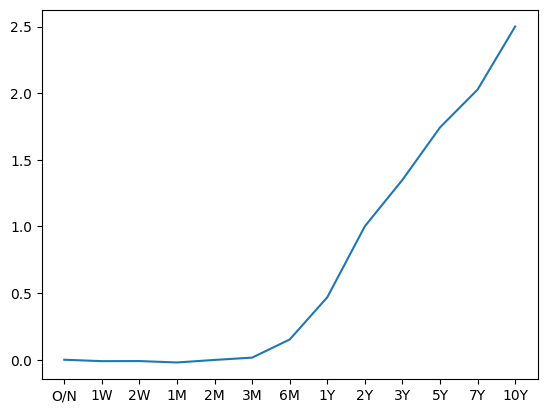

In [45]:
import matplotlib.pyplot as plt
plt.plot(term_premium_result)

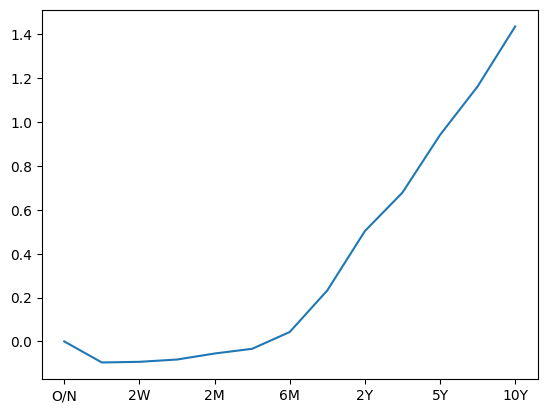

In [65]:
df2 = df_final.copy()
# for column in df2.columns:
    # print(df2)
df2 = df2.drop(columns = ['Month', 'slope_5Y_1M']).sub(df2['O/N'], axis=0)
fig = df2.mean(axis=0).plot()

In [74]:
df2.mean(axis=0)

O/N    0.000000
1W    -0.095964
2W    -0.092949
1M    -0.082516
2M    -0.055096
3M    -0.033573
6M     0.043057
1Y     0.232638
2Y     0.503283
3Y     0.678888
5Y     0.941672
7Y     1.162893
10Y    1.436352
dtype: float64

In [69]:
vars(fig)

{'_stale': True,
 'stale_callback': <function matplotlib.figure._stale_figure_callback(self, val)>,
 '_axes': <Axes: >,
 '_parent_figure': <Figure size 640x480 with 1 Axes>,
 '_transform': None,
 '_transformSet': False,
 '_visible': True,
 '_animated': False,
 '_alpha': None,
 'clipbox': None,
 '_clippath': None,
 '_clipon': True,
 '_label': '',
 '_picker': None,
 '_rasterized': False,
 '_agg_filter': None,
 '_mouseover': False,
 '_callbacks': <matplotlib.cbook.CallbackRegistry at 0x1a765de7260>,
 '_remove_method': <bound method FigureBase.delaxes of <Figure size 640x480 with 1 Axes>>,
 '_url': None,
 '_gid': None,
 '_snap': None,
 '_sketch': None,
 '_path_effects': [],
 '_sticky_edges': _XYPair(x=[], y=[]),
 '_in_layout': True,
 '_position': Bbox([[0.125, 0.10999999999999999], [0.9, 0.88]]),
 '_originalPosition': Bbox([[0.125, 0.10999999999999999], [0.9, 0.88]]),
 '_aspect': 'auto',
 '_adjustable': 'box',
 '_anchor': 'C',
 '_stale_viewlims': {'x': False, 'y': False},
 '_forward_naviga

In [73]:
fig[0,0].

TypeError: 'Axes' object is not subscriptable